In [1]:
import pandas as pd
import numpy as np
import glob, os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def manhattan(df, ax, alpha=-np.log10(0.05/1000000), figargs={"figsize":(14,8),"dpi":300}):

    colors = [ '#ED6B06',  "#00483F"]
    mpi_palette = sns.color_palette(colors)
    
    g = sns.scatterplot(
        data = df,
        x = 'cumulative_pos',
        y = 'LOG10P',
        hue = 'CHROM',
        palette = mpi_palette, #['indianred', 'mediumblue'] * 11 + ['indianred'],
        linewidth=0,
        s=6,
        zorder=2,
        ax=ax,
        legend=None,
        style=None
    )
    
    ax.plot([np.min(df["cumulative_pos"]), np.max(df["cumulative_pos"])], [alpha, alpha], "--", color="#4B1742")

    ax.set_xlabel('Chromosome', size=12)
    ax.set_ylabel('-Log10 P value', size=12)

    ax.set_xticks(df.groupby('CHROM')['cumulative_pos'].median())
    ax.tick_params(which='major', width=0.3, length=2, labelsize=8)

    ax.set_xticklabels(df['CHROM'].unique())
    
    ax.set_ylim(0, 20)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

def load_MOSTEST_sumstats(fn, out_fn=None):
    
    data = pd.read_csv(fn, sep="\t", compression="gzip")
    
    data = data[data["CHR"]!="CHR"]
    
    data.loc[data["CHR"] == "X", "CHR" ] = 23
    data.loc[data["CHR"] == "XY", "CHR" ] = 23
    
    data["CHR"] = data["CHR"].astype("int32")
    data["BP"] = data["BP"].astype("int64")
    data["PVAL"] = data["PVAL"].astype("float64")
    data["Z"] = data["Z"].astype("float32")
    data["N"] = data["N"].astype("float32")
    
    data.sort_values(by=["CHR", "BP"], inplace=True)
    
    data.reset_index(drop=True, inplace=True)
    
    #get cumulative position
    data = get_cumulative_pos(data)
    
    data["LOGP"] = -np.log10(data["PVAL"].astype("float64"))

    if out_fn is not None:
        data.to_csv(out_fn, sep="\t", compression="gzip")
    
    return data

def get_cumulative_pos(df):
    running_pos = float(0)

    cumulative_pos = []

    for chrom, group_df in df.groupby('CHR'):
        chr_df = np.add(group_df['BP'].astype("int64"), running_pos)
        cumulative_pos.append(chr_df)
        running_pos += float(group_df['BP'].max())

    df['cumulative_pos'] = pd.concat(cumulative_pos)
    
    return df

C:\Users\Jitse\AppData\Local\Temp\ipykernel_18816\3920628753.py:6: UserWarning: 
The palette list has fewer values (2) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.scatterplot(


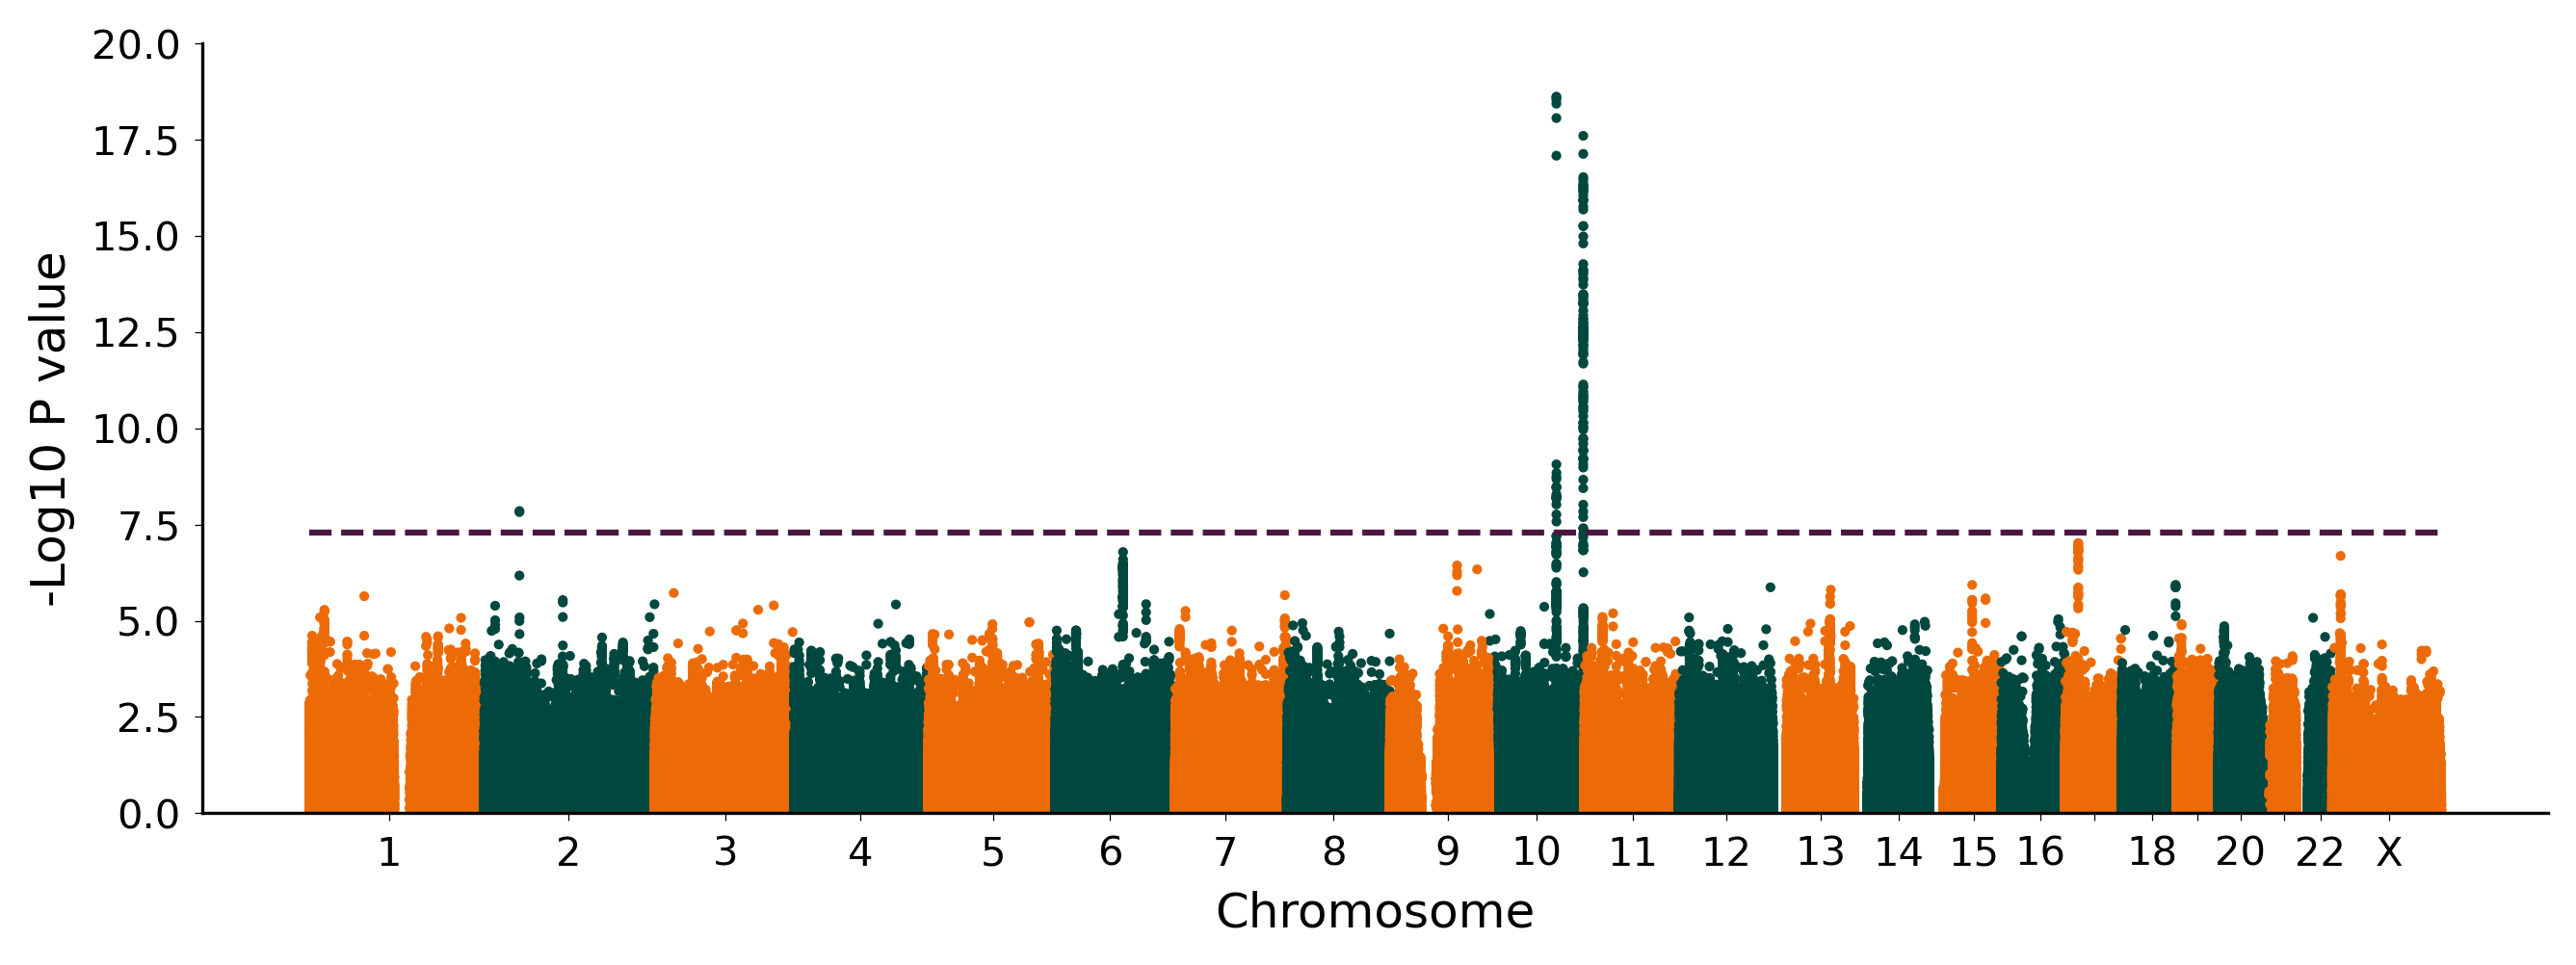

In [3]:
fn=r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\to_laptop\gwas\CONGRADS_gwas_cmap_65k_multi.regenie.gz"

data = pd.read_csv(fn, sep="\t")
data = data[data["P"] < 0.9]

base_path = r"C:\Users\Jitse\OneDrive\Work\02_UKB_HCP_rest_lang_lat\figs_new"
fig_args = {"figsize":(17.8/1.7,6/1.7),"dpi":300}
fig, ax = plt.subplots(1,1, **fig_args)
manhattan(data, ax)

xticklabels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, "", 18, "", 20, "", 22, "X"]
ax.set_xticklabels(xticklabels)
ax.tick_params(which='major', width=0.3, length=2, labelsize=10)

#fig.suptitle("Multivariate GWAS of trend surface coefficients of all 4 ROIs")
plt.savefig(os.path.join(base_path, "mvGWAS_cmap.png"))